# This file serves to postprocess model data (from monthly means speratae for rampup and rampdown) to concatenated

author: Eike E. Köhn....... 
date: Aug 20, 2025....... 
instructions: can be run with environment "conda env:pangeo-meso-2024.01.22" on spirit1

## Import packages

In [2]:
print('Loading packages...')
import sys
sys.path.append('../00_modules/.')
from import_packages import PackageGetter
globals().update(PackageGetter.import_standard_packages_for_analysis_and_plotting())
globals().update(PackageGetter.import_custom_packages())
misc_params = Params.additional_misc_params()

from datetime import date
from dateutil.relativedelta import relativedelta

Loading packages...


## Set the parameters for the analysis of the 1pctCO2-cdr run

In [3]:
print('Setting parameters...')
run_params = Params.standard_set_1pctCO2cdr()  #Params.test_set_1pctCO2cdr() #

Setting parameters...


## Now postprocess the model output, by looping over the models

### 1. set the variable to be treated

In [4]:
variable = 'tas'

if variable in ['hur','thetao','so','dissic','talk','po4']:
    depth_to_analyze = '1' # None
else:
    depth_to_analyze = ''

### 2. get the raw data paths (for 1pctco2, 1pctco2-cdr, and if available piControl)

In [6]:
def get_domain(variable):
    if variable in ['psl','hurs','hur','tas']:
        domain = 'A'
    elif variable in ['siconc']:
        domain = 'SI'
    else:
        domain = 'O'
    return domain

def get_temporal_resolution(rparam,experiment,variable):
    if variable in ['dissic'] and experiment in ['1pctCO2','1pctCO2-cdr'] and rparam.model in ['CESM2','ACCESS-ESM1-5']:
        temporal_resolution = 'yr'
    else:
        temporal_resolution = 'mon'
    return temporal_resolution

def get_unit(variable):
    if variable in ['tos','thetao']:
        unit = '°C'
    elif variable in ['sos','so']:
        unit = 'psu'
    elif variable == 'psl':
        unit = 'Pa'
    elif variable in ['hurs','hur']:
        unit = '%'
    elif variable in ['dissic','talk']:
        unit = 'mol m-3'
    elif variable in ['fgco2']:
        unit = 'kg m-2 s-1'
    elif variable == 'tas':
        unit = 'K'
    return unit

def get_raw_filepaths(run_params,variable):
    root_dir = '/data/ekoehn/CMIP6_derived'
    raw_filepaths = dict()
    for key in run_params.keys():

        rparam = run_params[key]

        # get the domain
        domain = get_domain(variable)

        # put the paths into the dictionary
        raw_filepaths_key = dict()

        # get the data paths
        experiments = ['1pctCO2','1pctCO2-cdr']

        for experiment in experiments:
            # get the temporal resolution
            temporal_resolution = get_temporal_resolution(rparam,experiment,variable)
            filepath = f'{root_dir}/{variable}{depth_to_analyze}/{experiment}/{domain}{temporal_resolution}'
            filename = f'{variable}{depth_to_analyze}_{domain}{temporal_resolution}_{rparam.model}_{experiment}_{rparam.member}_gr_*.nc'
            #print(f'{filepath}/{filename}')
            print(f'{filepath}/{filename}')
            available_paths = glob.glob(f'{filepath}/{filename}')
            if len(available_paths)==0:
                print(f'{experiment}, {rparam.model}: No file available')
                raw_filepaths_key[experiment] = None
            elif len(available_paths)>1:
                print(f'{experiment}, {rparam.model}: More than one file available')
                raw_filepaths_key[experiment] = None
            else:
                raw_filepaths_key[experiment] = available_paths[0]
        
        raw_filepaths[key] = raw_filepaths_key
    return raw_filepaths

raw_data_paths = get_raw_filepaths(run_params,variable)

/data/ekoehn/CMIP6_derived/tas/1pctCO2/Amon/tas_Amon_UKESM1-0-LL_1pctCO2_r1i1p1f2_gr_*.nc
/data/ekoehn/CMIP6_derived/tas/1pctCO2-cdr/Amon/tas_Amon_UKESM1-0-LL_1pctCO2-cdr_r1i1p1f2_gr_*.nc
/data/ekoehn/CMIP6_derived/tas/1pctCO2/Amon/tas_Amon_NorESM2-LM_1pctCO2_r1i1p1f1_gr_*.nc
/data/ekoehn/CMIP6_derived/tas/1pctCO2-cdr/Amon/tas_Amon_NorESM2-LM_1pctCO2-cdr_r1i1p1f1_gr_*.nc
/data/ekoehn/CMIP6_derived/tas/1pctCO2/Amon/tas_Amon_MIROC-ES2L_1pctCO2_r1i1p1f2_gr_*.nc
/data/ekoehn/CMIP6_derived/tas/1pctCO2-cdr/Amon/tas_Amon_MIROC-ES2L_1pctCO2-cdr_r1i1p1f2_gr_*.nc
/data/ekoehn/CMIP6_derived/tas/1pctCO2/Amon/tas_Amon_CNRM-ESM2-1_1pctCO2_r1i1p1f2_gr_*.nc
/data/ekoehn/CMIP6_derived/tas/1pctCO2-cdr/Amon/tas_Amon_CNRM-ESM2-1_1pctCO2-cdr_r1i1p1f2_gr_*.nc
/data/ekoehn/CMIP6_derived/tas/1pctCO2/Amon/tas_Amon_ACCESS-ESM1-5_1pctCO2_r1i1p1f1_gr_*.nc
/data/ekoehn/CMIP6_derived/tas/1pctCO2-cdr/Amon/tas_Amon_ACCESS-ESM1-5_1pctCO2-cdr_r1i1p1f1_gr_*.nc
/data/ekoehn/CMIP6_derived/tas/1pctCO2/Amon/tas_Amon_CESM2_1

In [7]:
raw_data_paths

{'2': {'1pctCO2': '/data/ekoehn/CMIP6_derived/tas/1pctCO2/Amon/tas_Amon_UKESM1-0-LL_1pctCO2_r1i1p1f2_gr_185001-199912.nc',
  '1pctCO2-cdr': '/data/ekoehn/CMIP6_derived/tas/1pctCO2-cdr/Amon/tas_Amon_UKESM1-0-LL_1pctCO2-cdr_r1i1p1f2_gr_199001-263912.nc'},
 '3': {'1pctCO2': '/data/ekoehn/CMIP6_derived/tas/1pctCO2/Amon/tas_Amon_NorESM2-LM_1pctCO2_r1i1p1f1_gr_000101-015012.nc',
  '1pctCO2-cdr': '/data/ekoehn/CMIP6_derived/tas/1pctCO2-cdr/Amon/tas_Amon_NorESM2-LM_1pctCO2-cdr_r1i1p1f1_gr_014101-039912.nc'},
 '4': {'1pctCO2': '/data/ekoehn/CMIP6_derived/tas/1pctCO2/Amon/tas_Amon_MIROC-ES2L_1pctCO2_r1i1p1f2_gr_185001-199912.nc',
  '1pctCO2-cdr': '/data/ekoehn/CMIP6_derived/tas/1pctCO2-cdr/Amon/tas_Amon_MIROC-ES2L_1pctCO2-cdr_r1i1p1f2_gr_198901-249012.nc'},
 '5': {'1pctCO2': '/data/ekoehn/CMIP6_derived/tas/1pctCO2/Amon/tas_Amon_CNRM-ESM2-1_1pctCO2_r1i1p1f2_gr_185001-199912.nc',
  '1pctCO2-cdr': '/data/ekoehn/CMIP6_derived/tas/1pctCO2-cdr/Amon/tas_Amon_CNRM-ESM2-1_1pctCO2-cdr_r1i1p1f2_gr_199001-2

## 3. open the datafiles and select the respective slices

In [8]:
# Function to add one month manually
def add_one_month(t):
    return pd.Timestamp(t) + relativedelta(months=1)
    
for key in run_params.keys():
    print(key)

    rparam = run_params[key]

    if raw_data_paths[key]['1pctCO2'] == None and raw_data_paths[key]['1pctCO2-cdr'] == None: 
        print(f'variable {variable} not available for the model: {rparam.model}')
        continue
        
    ds_up = xr.open_dataset(raw_data_paths[key]['1pctCO2'])#.groupby('time.year').mean('time')
    ds_dn = xr.open_dataset(raw_data_paths[key]['1pctCO2-cdr'])#.groupby('time.year').mean('time')

    temporal_resolution = get_temporal_resolution(rparam,rparam.experiment,variable)
    if temporal_resolution == 'mon':
        factor = 12
    elif temporal_resolution == 'yr':
        factor = 1

    # How long is the rampup (MIROC and CanESM have not the standard 140 year rampup)
    if rparam.model == 'MIROC-ES2L':
        numyears = 139 
    elif rparam.model == 'CanESM5':
        numyears = 141
    else:
        numyears = 140

    # get the rampup
    ds_up = ds_up.isel(time=slice(0,numyears*factor))
    if temporal_resolution == 'mon':
        time_up = pd.date_range(start='1850-01', periods=numyears*factor, freq='MS')
    elif temporal_resolution == 'yr':
        time_up = pd.date_range(start='1850-01', periods=numyears*factor, freq='YS')        
    ds_up['time'] = time_up

    # get the rampdown
    ds_dn = ds_dn.isel(time=slice(0,(340-numyears)*factor))
    if temporal_resolution == 'mon':
        time_dn = pd.date_range(start=f'{1850+numyears}-01', periods=(340-numyears)*factor, freq='MS')
    elif temporal_resolution == 'yr':
        time_dn = pd.date_range(start=f'{1850+numyears}-01', periods=(340-numyears)*factor, freq='YS') 
    ds_dn['time'] = time_dn

    # put the together into one run
    assert ds_up[variable].attrs['units'] == ds_dn[variable].attrs['units']
    ds = xr.concat([ds_up,ds_dn],dim='time').squeeze()

    # Now start the processing. First set up the final dataset
    ds_all = xr.Dataset()
    
    # now calculate annual means 
    annual_means = ds.groupby('time.year').mean('time')#.compute()
    ds_all['annual_means'] = annual_means[variable]
    
    # now calculate the seasonal means and put them into the right shape
    if temporal_resolution == 'mon':
        seasonal_means_dum = ds.resample(time='QS-DEC').mean('time')   # note the December of the first and last year
        seasonal_means_dum['time'] = xr.DataArray([add_one_month(t) for t in seasonal_means_dum['time'].values], dims="time") 
        seasonal_means_dum = seasonal_means_dum.isel(time=slice(None,-1))
        # First: Assign year and season from time
        seasonal_means_dummy = seasonal_means_dum.assign_coords({"year": seasonal_means_dum['time'].dt.year,"season": seasonal_means_dum['time'].dt.season})
        # Then group by year and season separately
        seasonal_means = (seasonal_means_dummy.groupby("year").apply(lambda x: x.groupby("season").first()))  
        # Put the seasonal means into the right order
        seasonal_means = seasonal_means.sel(season=['DJF', 'MAM', 'JJA', 'SON'])

        # put them into the final ds_all dataset
        ds_all['seasonal_means']  = seasonal_means[variable]
        
        # now calculate the annual (arg)min and (arg)max and seasonal amplitude (min/max)
        include_min_max = False
        if include_min_max:
            ds_min = ds.groupby('time.year').min(dim='time')
            ds_max = ds.groupby('time.year').max(dim='time')
            ds_all['annual_min']    = ds_min[variable]
            ds_all['annual_max']    = ds_max[variable]
            
            ds_argmin = ds.groupby('time.year').reduce(np.argmin, dim='time')
            ds_argmax = ds.groupby('time.year').reduce(np.argmax, dim='time')
            ds_all['annual_argmin'] = ds_argmin[variable].astype('int8')
            ds_all['annual_argmax'] = ds_argmax[variable].astype('int8')

    else:
        print('No seasonality to be computed')

    # now add some attributes to the final dataset
    ds_all.attrs['variable'] = variable
    ds_all.attrs['depth_to_analyze'] = depth_to_analyze
    ds_all.attrs['unit'] = ds_up[variable].attrs['units']
    ds_all.attrs['author'] = 'Eike E. Köhn'
    ds_all.attrs['creation_date'] = date.today().isoformat()
    ds_all.attrs['input_files'] = [raw_data_paths[key]['1pctCO2'],raw_data_paths[key]['1pctCO2-cdr']]
    ds_all.attrs['numyears_of_rampup'] = numyears

    print(ds_all)
    if include_min_max == True:
        fsc = 1
    else:
        fsc = 0.66
    print(f'should have a size of about {630*fsc} MB')

    # now save the dataset
    save_dir = f'/data/ekoehn/projects/arctic_acidification_reversibility/data/processed_data_1pctCO2-cdr/{variable}{depth_to_analyze}'
    os.makedirs(save_dir, exist_ok=True)
    save_filename = f'{variable}{depth_to_analyze}_{rparam.model}_processed.nc'
    ds_all.to_netcdf(f'{save_dir}/{save_filename}')

2
<xarray.Dataset>
Dimensions:         (lon: 360, lat: 180, year: 340, season: 4)
Coordinates:
  * lon             (lon) float64 0.0 1.0 2.0 3.0 ... 356.0 357.0 358.0 359.0
  * lat             (lat) float64 -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
    height          float64 1.5
  * year            (year) int64 1850 1851 1852 1853 ... 2186 2187 2188 2189
  * season          (season) object 'DJF' 'MAM' 'JJA' 'SON'
Data variables:
    annual_means    (year, lat, lon) float32 226.8 226.8 226.8 ... 257.6 257.6
    seasonal_means  (year, season, lat, lon) float32 240.6 240.6 ... 261.1 261.1
Attributes:
    variable:            tas
    depth_to_analyze:    
    unit:                K
    author:              Eike E. Köhn
    creation_date:       2025-09-08
    input_files:         ['/data/ekoehn/CMIP6_derived/tas/1pctCO2/Amon/tas_Am...
    numyears_of_rampup:  140
should have a size of about 415.8 MB
3
<xarray.Dataset>
Dimensions:         (lon: 360, lat: 180, year: 340, season: 4)
Coordina

# Demo how the rampups are differently long

/data/ekoehn/CMIP6_derived/tas/1pctCO2/Amon/tas_Amon_UKESM1-0-LL_1pctCO2_r1i1p1f2_gr_185001-199912.nc
/data/ekoehn/CMIP6_derived/tas/1pctCO2-cdr/Amon/tas_Amon_UKESM1-0-LL_1pctCO2-cdr_r1i1p1f2_gr_199001-263912.nc


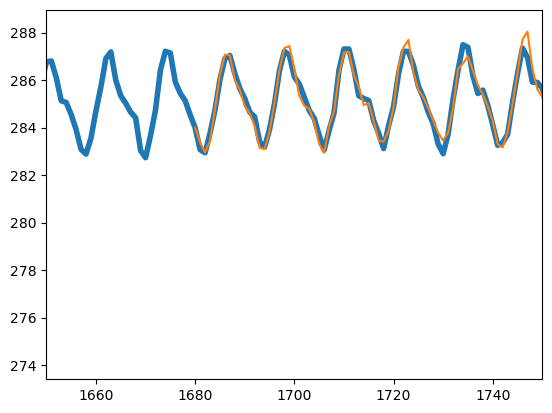

/data/ekoehn/CMIP6_derived/tas/1pctCO2/Amon/tas_Amon_NorESM2-LM_1pctCO2_r1i1p1f1_gr_000101-015012.nc
/data/ekoehn/CMIP6_derived/tas/1pctCO2-cdr/Amon/tas_Amon_NorESM2-LM_1pctCO2-cdr_r1i1p1f1_gr_014101-039912.nc


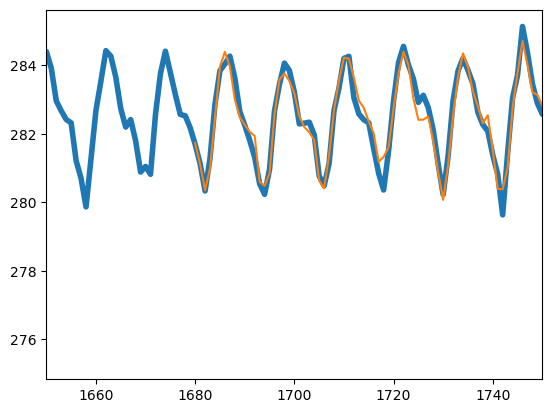

/data/ekoehn/CMIP6_derived/tas/1pctCO2/Amon/tas_Amon_MIROC-ES2L_1pctCO2_r1i1p1f2_gr_185001-199912.nc
/data/ekoehn/CMIP6_derived/tas/1pctCO2-cdr/Amon/tas_Amon_MIROC-ES2L_1pctCO2-cdr_r1i1p1f2_gr_198901-249012.nc


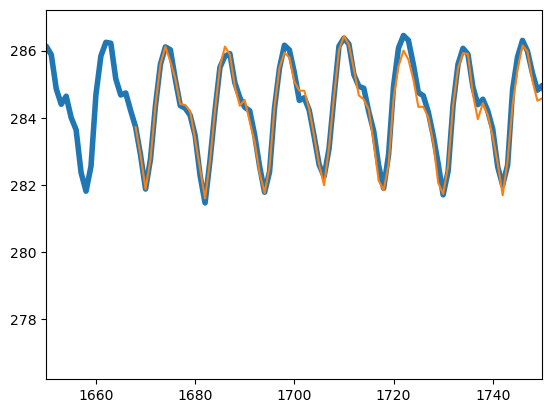

/data/ekoehn/CMIP6_derived/tas/1pctCO2/Amon/tas_Amon_CNRM-ESM2-1_1pctCO2_r1i1p1f2_gr_185001-199912.nc
/data/ekoehn/CMIP6_derived/tas/1pctCO2-cdr/Amon/tas_Amon_CNRM-ESM2-1_1pctCO2-cdr_r1i1p1f2_gr_199001-218912.nc


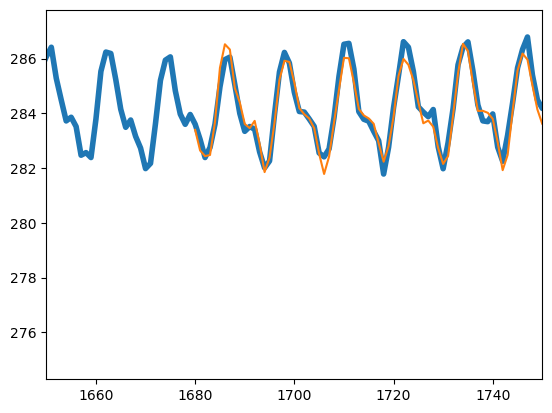

/data/ekoehn/CMIP6_derived/tas/1pctCO2/Amon/tas_Amon_ACCESS-ESM1-5_1pctCO2_r1i1p1f1_gr_010101-025012.nc
/data/ekoehn/CMIP6_derived/tas/1pctCO2-cdr/Amon/tas_Amon_ACCESS-ESM1-5_1pctCO2-cdr_r1i1p1f1_gr_024101-100012.nc


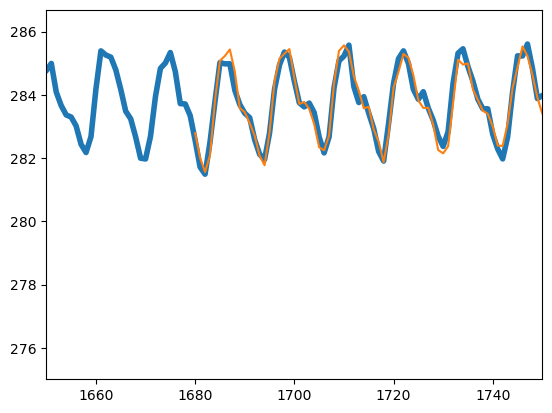

/data/ekoehn/CMIP6_derived/tas/1pctCO2/Amon/tas_Amon_CESM2_1pctCO2_r1i1p1f1_gr_000101-015012.nc
/data/ekoehn/CMIP6_derived/tas/1pctCO2-cdr/Amon/tas_Amon_CESM2_1pctCO2-cdr_r1i1p1f1_gr_000101-020012.nc


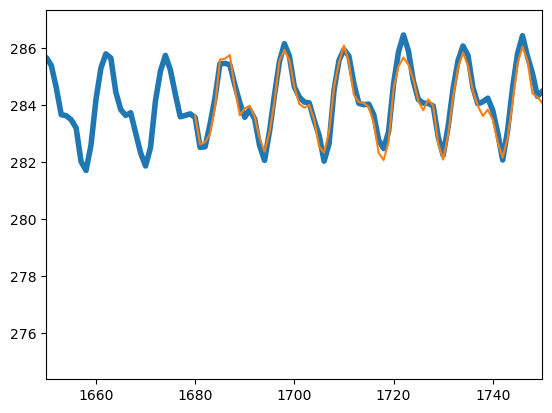

/data/ekoehn/CMIP6_derived/tas/1pctCO2/Amon/tas_Amon_CanESM5_1pctCO2_r1i1p2f1_gr_185001-200012.nc
/data/ekoehn/CMIP6_derived/tas/1pctCO2-cdr/Amon/tas_Amon_CanESM5_1pctCO2-cdr_r1i1p2f1_gr_199101-229012.nc


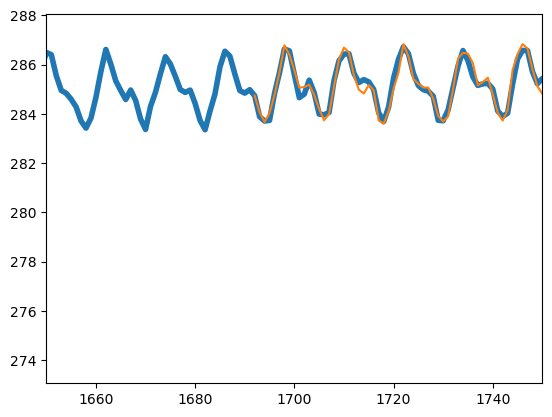

/data/ekoehn/CMIP6_derived/tas/1pctCO2/Amon/tas_Amon_GFDL-ESM4_1pctCO2_r1i1p1f1_gr_000101-015012.nc
/data/ekoehn/CMIP6_derived/tas/1pctCO2-cdr/Amon/tas_Amon_GFDL-ESM4_1pctCO2-cdr_r1i1p1f1_gr_014101-034012.nc


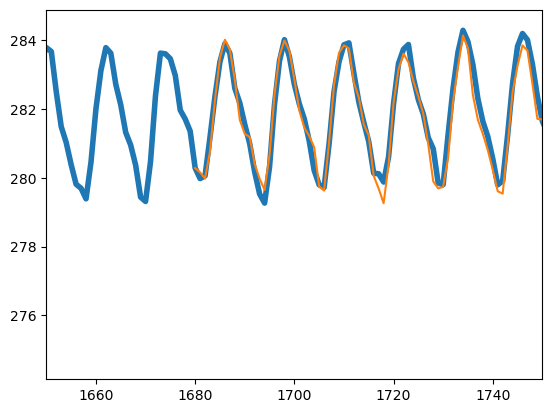

In [9]:
for key in run_params.keys():
    ds_up = xr.open_dataset(raw_data_paths[key]['1pctCO2']).mean(('lat','lon'))#.groupby('time.year').mean('time')
    ds_dn = xr.open_dataset(raw_data_paths[key]['1pctCO2-cdr']).mean(('lat','lon'))#.groupby('time.year').mean('time')
    print(raw_data_paths[key]['1pctCO2'])
    print(raw_data_paths[key]['1pctCO2-cdr'])

    if run_params[key].model == 'MIROC-ES2L':
        nummonths_offset = 139 * 12 
    elif run_params[key].model in ['CanESM5']:
        nummonths_offset = 141 * 12 
    else:
        nummonths_offset = 140 * 12 

    # choose a random location
    loncho = 160
    latcho = 90
    
    fig, ax = plt.subplots()
    x_up = np.arange(len(ds_up[variable]))#.isel(lon=loncho,lat=latcho)))
    plt.plot(x_up,ds_up[variable],linewidth=4) # .isel(lon=loncho,lat=latcho)
    x_dn = np.arange(len(ds_dn[variable])) + nummonths_offset # .isel(lon=loncho,lat=latcho)
    plt.plot(x_dn, ds_dn[variable]) #.isel(lon=loncho,lat=latcho))
    plt.xlim([1650,1750])
    plt.show()